# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Moho Goswami

**ID**: mg2297

> **Due Date**
>
> Thursday, 10/23/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\mohog\hw3-mohogos`


In [1]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Given constants
* U = 6 km/day
* k_a = 0.55/day
* k_c = 0.35/day
* k_n = 0.25/day
* C_s = 10 mg/L
* x = 50 km

Analytic Solution Equation (ignoring photosynthesis, respiration, and benthal uptake)
\begin{align*}
C(x) &= Cs(1-a_1) + C0a_1 - B0a_2 - N0a_3
\end{align*}

Determine concentration at x = 0 km
\begin{align*}
a_1 &= e^{-\frac{0.55 \cdot 0}{6}} = e^0 = 1 \\
a_2 &= \left( \frac{0.35}{0.55 - 0.35} \right) \left( e^{-\frac{0.35 \cdot 0}{6}} - e^{-\frac{0.55 \cdot 0}{6}} \right) \\
&= 1.75 \cdot (1 - 1) = 0 \\
a_3 &= \left( \frac{0.25}{0.55 - 0.25} \right) \left( e^{-\frac{0.25 \cdot 0}{6}} - e^{-\frac{0.55 \cdot 0}{6}} \right) \\
&= 0.833 \cdot (1 - 1) = 0 \\
\\
C(x) &= 10(1 - a_1) + C_0 a_1 - B_0 a_2 - N_0 a_3 \\
C(x=0) &= 10(1 - 1) + C_0(1) - B_0(0) - N_0(0) = C_0
\end{align*}

Determine values of C0, B0, and N0
* Total flow: 100,000 m3/day + 10,000 m3/day = 110,000 m3/day = 110000000 L/day
* Ratio: river inflow = 10/11, waste stream 1 = 1/11
\begin{align*}
C_0 &= (7.5~\text{mg/L}) \cdot \left( \frac{10}{11} \right) + (5~\text{mg/L}) \cdot \left( \frac{1}{11} \right) \\
&= 7.27~\text{mg/L} \\
B_0 &= (5~\text{mg/L}) \cdot \left( \frac{10}{11} \right) + (50~\text{mg/L}) \cdot \left( \frac{1}{11} \right) \\
&= 9.09~\text{mg/L} \\
N_0 &= (5~\text{mg/L}) \cdot \left( \frac{10}{11} \right) + (35~\text{mg/L}) \cdot \left( \frac{1}{11} \right) \\
&= 7.72~\text{mg/L}
\end{align*}

Total dissolved oxygen concentration, x = 0
\begin{align*}
C(x=0) &= 7.27
\end{align*}

Determine a values and DO concentration at x = 15 km
\begin{align*}
a_1 &= e^{-\frac{0.55 \cdot 15}{6}} = 0.253 \\
a_2 &= \left( \frac{0.35}{0.55 - 0.35} \right) \left( e^{-\frac{0.35 \cdot 15}{6}} - e^{-\frac{0.55 \cdot 15}{6}} \right) \\
&= 1.75 \cdot (0.164) = 0.287 \\
a_3 &= \left( \frac{0.25}{0.55 - 0.25} \right) \left( e^{-\frac{0.25 \cdot 15}{6}} - e^{-\frac{0.55 \cdot 15}{6}} \right) \\
&= 0.833 \cdot (0.2824) = 0.235 \\
C(x) &= 10(1 - 0.253) + C_0(0.253) - B_0(0.287) - N_0(0.235) \\
C(x=15) &= 10(0.747) + C_0(0.253) - B_0(0.287) - N_0(0.235) \\
\end{align*}

Apply previous initial concentrations
\begin{align*}
C(x=15) &= 10(0.747) + 7.27(0.253) - 9.09(0.287) - 7.72(0.235) \\
C(x=15) &= 4.89
\end{align*}

Account for decay of CBOD and NBOD before mixing at 15 m
\begin{align*}
B_0 &= 9.09 \cdot e^{-\frac{0.35 \cdot 15}{6}} \\
&= 3.79 \\
N_0 &= 7.72 \cdot e^{-\frac{0.25 \cdot 15}{6}} \\
&= 4.13
\end{align*}


Detemine values of C0, B0, and N0 after mixing with waste stream 2
* Total flow: 110,000 m3/day + 15,000 m3/day = 125,000 m3/day
* Ratio: river + stream 1 = 22/25, stream 2 = 3/25

\begin{align*}
C_0 &= (4.89~\text{mg/L}) \cdot \left( \frac{22}{25} \right) + (5~\text{mg/L}) \cdot \left( \frac{3}{25} \right) \\
&= 4.90~\text{mg/L} \\
B_0 &= (3.79~\text{mg/L}) \cdot \left( \frac{22}{25} \right) + (45~\text{mg/L}) \cdot \left( \frac{3}{25} \right) \\
&= 8.735~\text{mg/L} \\
N_0 &= (4.13~\text{mg/L}) \cdot \left( \frac{22}{25} \right) + (35~\text{mg/L}) \cdot \left( \frac{3}{25} \right) \\
&= 7.834~\text{mg/L}
\end{align*}

Total dissolved oxygen concentration, x = 15
\begin{align*}
C(x=15) &= 10(0.747) + 4.90(0.253) - 8.735(0.287) - 7.834(0.235) \\
C(x=15) &= 4.36
\end{align*}

| Parameter | \( x = 0 km \) | \( x = 15 km \) |
|:----------:|:----------------:|:----------------:|
| a_1 | 1.000 | 0.253 |
| a_2  | 0.000 | 0.287 |
| a_3  | 0.000 | 0.235 |
| C_0  | 7.27 | 4.90 |
| B_0  | 9.09 | 8.735 |
| N_0  | 7.72 | 7.834 |
| C(x) | 7.27 | 4.36 |

Minimum DO Concentration: 3.756 mg/L
Occurs at: 22.5 km downstream


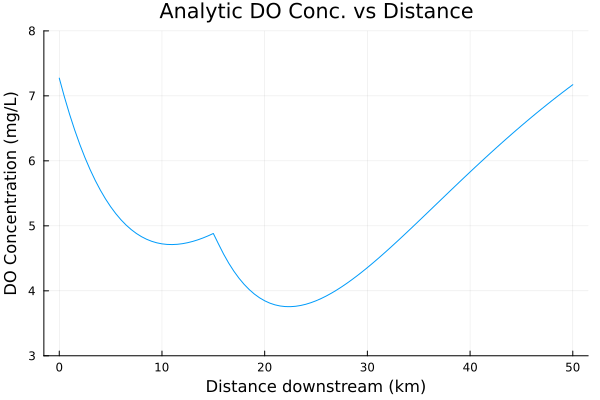

In [86]:
# Constants
U = 6.0            # km/day
k_a = 0.55         # /day
k_c = 0.35         # /day
k_n = 0.25         # /day
C_s = 10.0         # mg/L

# Flows (m³/day)
Q_r = 100000.0
Q1  = 10000.0
Q2  = 15000.0

Q_m1 = Q_r + Q1 
Q_total = Q_m1 + Q2

# Inflow concentrations
C_r = 7.5
B_r = 5.0
N_r = 5.0

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0
N1_ws = 35.0

# Waste stream 2
C2_ws = 5.0
B2_ws = 45.0
N2_ws = 35.0

# Mixing after first waste stream
C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

# Recalibrate values at 15 km before mixing
t = 15 / U
a1_15 = exp(-k_a * t)
a2_15 = (k_c / (k_a - k_c)) * (exp(-k_c * t) - exp(-k_a * t))
a3_15 = (k_n / (k_a - k_n)) * (exp(-k_n * t) - exp(-k_a * t))
C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
B_15 = B0_1 * exp(-k_c * t)
N_15 = N0_1 * exp(-k_n * t)

# Mixing with second waste stream at 15 km
C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

# Define analytic functions
function do_analytic_1(C0, B0, N0, k_a, k_n, k_c, C_s, U)
    x1 = 0:0.5:15
    C1 = Float64[]

    for x in x1
        a1 = exp(-k_a * x / U)
        a2 = (k_c / (k_a - k_c)) * (exp(-k_c * x / U) - exp(-k_a * x / U))
        a3 = (k_n / (k_a - k_n)) * (exp(-k_n * x / U) - exp(-k_a * x / U))
        C = C_s * (1 - a1) + C0 * a1 - B0 * a2 - N0 * a3
        push!(C1, C)
    end

    return x1, C1
end

function do_analytic_2(C0, B0, N0, k_a, k_n, k_c, C_s, U)
    x2 = 15:0.5:50
    C2 = Float64[]

    for x in x2
        dx = x - 15
        a1 = exp(-k_a * dx / U)
        a2 = (k_c / (k_a - k_c)) * (exp(-k_c * dx / U) - exp(-k_a * dx / U))
        a3 = (k_n / (k_a - k_n)) * (exp(-k_n * dx / U) - exp(-k_a * dx / U))
        C = C_s * (1 - a1) + C0 * a1 - B0 * a2 - N0 * a3
        push!(C2, C)
    end

    return x2, C2
end

x1, C1 = do_analytic_1(C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
x2, C2 = do_analytic_2(C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)

DO_distance_analytic = vcat(x1, x2[2:end])      
DO_concentration_analytic = vcat(C1, C2[2:end])

min_DO = minimum(DO_concentration_analytic)
min_index = argmin(DO_concentration_analytic)
min_distance = DO_distance_analytic[min_index]

println("Minimum DO Concentration: $(round(min_DO, digits=3)) mg/L")
println("Occurs at: $(min_distance) km downstream")
plot(DO_distance_analytic, DO_concentration_analytic, xlabel = "Distance downstream (km)", ylabel = "DO Concentration (mg/L)", title = "Analytic DO Conc. vs Distance", legend = false, ylim = (3, 8))

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Minimum DO Concentration: 3.692 mg/L
Occurs at: 22.5 km downstream


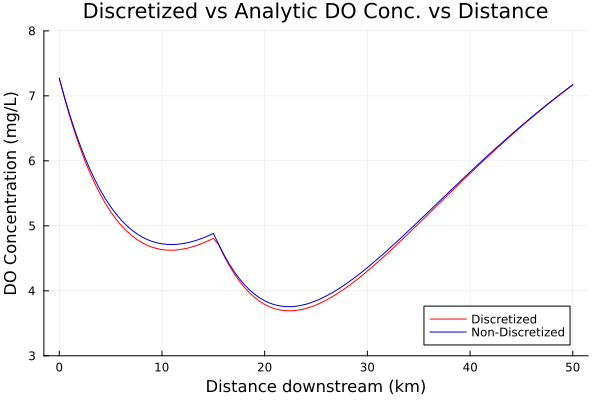

In [87]:
# Constants
U = 6.0            # km/day
k_a = 0.55         # /day
k_c = 0.35         # /day
k_n = 0.25         # /day
C_s = 10.0         # mg/L
Δx = 0.5           # step size

# Flows (m³/day)
Q_r = 100_000.0
Q1  = 10_000.0
Q2  = 15_000.0

Q_m1 = Q_r + Q1 
Q_total = Q_m1 + Q2

# Inflow concentrations
C_r = 7.5
B_r = 5.0
N_r = 5.0

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0
N1_ws = 35.0

# Waste stream 2
C2_ws = 5.0
B2_ws = 45.0
N2_ws = 35.0

# Mixing after first waste stream
C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

# Recalibrate values at 15 m before mixing
t = 15 / U
a1_15 = 0.253
a2_15 = 0.287
a3_15 = 0.235
C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
B_15 = B0_1 * exp(-k_c * t)
N_15 = N0_1 * exp(-k_n * t)
C_15

# Mixing decayed stream with second waste stream only
C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

# Defining distance range and DO concentration array
DO_distance_discretized = 0:0.5:50
DO_concentration_discretized = Float64[]

# Defining function
function do_numerical(L, Δx, CO, BO, NO, ka, kn, kc, Cs, U)
    n = Int(L / Δx)
    C = zeros(n + 1)
    B = zeros(n + 1)
    N = zeros(n + 1)
    C[1] = CO
    B[1] = BO
    N[1] = NO
    for i = 1:n
        B[i+1] = B[i] * exp(-kc * Δx / U)
        N[i+1] = N[i] * exp(-kn * Δx / U)
        C[i+1] = C[i] + (Δx / U) * (ka * (Cs - C[i]) - kc * B[i] - kn * N[i])
    end
    return (C, B, N)
end

L1 = 15.0
C1, B1, N1 = do_numerical(L1, Δx, C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
L2 = 35.0
C2, B2, N2 = do_numerical(L2, Δx, C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)
DO_concentration_discretized = vcat(C1, C2[2:end])

min_DO = minimum(DO_concentration_discretized)
min_index = argmin(DO_concentration_discretized)
min_distance = DO_distance_discretized[min_index]

println("Minimum DO Concentration: $(round(min_DO, digits=3)) mg/L")
println("Occurs at: $(min_distance) km downstream")
plot(DO_distance_discretized, DO_concentration_discretized, xlabel="Distance downstream (km)", ylabel="DO Concentration (mg/L)", title="Discretized vs Analytic DO Conc. vs Distance", legend=true, linecolor=[:red], label="Discretized",ylim=(3,8))
plot!(DO_distance_analytic, DO_concentration_analytic, legend = true, linecolor=[:mediumblue], label="Non-Discretized")

Although the discretized solution identifies the minimum DO concentration as being at the same location as in the non-discretized solution - 22.5 km downstream - the minimum value has slightly decreased from 3.75 to 3.69 mg/L. The discretized solution introduces greater complexity in the calculations by making the DO concentration, CBOD, and NBOD be time-varying with every increase in the step size of 0.5 km. 

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Applying 5% margin of safety to compliance minimum:
\begin{align*}
C(x) &>= 4 * 1.05 = 4.2 mg/L \\
\end{align*}

#### Approach
The following code builds on the code from 1.1, adds a variable R representing the amount of reduction such that (1-R)*100 is the percent removal of organic waste, multiplies this variable by both B#_ws and N#_ws (where the # represents the specific waste stream), and then solves for the minimum level of DO. I achieved the results by manually altering the value of R until the minimum DO concentration was outputted as approximately 4.200 mg/L for both scenarios. The results are shown below.

### Waste 1 treated, waste 2 untreated


Minimum DO Concentration: 4.200360487612862) mg/L
Occurs at: 22.5 km downstream
Minimum Level of Treatment: 27.58 %


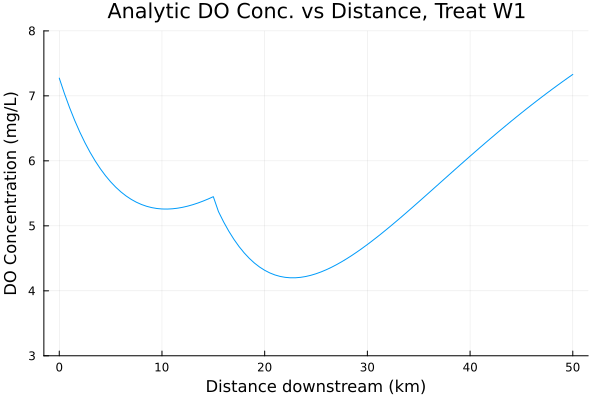

In [88]:
# Constants
U = 6.0            # km/day
k_a = 0.55         # /day
k_c = 0.35         # /day
k_n = 0.25         # /day
C_s = 10.0         # mg/L

# Flows (m³/day)
Q_r = 100000.0
Q1  = 10000.0
Q2  = 15000.0

Q_m1 = Q_r + Q1 
Q_total = Q_m1 + Q2

# Inflow concentrations
C_r = 7.5
B_r = 5.0
N_r = 5.0

# Add variable R representing reduction of CBOD + NBOD
R = 0.7242

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0*R
N1_ws = 35.0*R

# Waste stream 2
C2_ws = 5.0
B2_ws = 45.0
N2_ws = 35.0

# Mixing after first waste stream
C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

# Recalibrate values at 15 km before mixing
t = 15 / U
a1_15 = exp(-k_a * t)
a2_15 = (k_c / (k_a - k_c)) * (exp(-k_c * t) - exp(-k_a * t))
a3_15 = (k_n / (k_a - k_n)) * (exp(-k_n * t) - exp(-k_a * t))
C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
B_15 = B0_1 * exp(-k_c * t)
N_15 = N0_1 * exp(-k_n * t)

# Mixing with second waste stream at 15 km
C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

# Define analytic functions
function do_analytic_1(C0, B0, N0, k_a, k_n, k_c, C_s, U)
    x1 = 0:0.5:15
    C1 = Float64[]

    for x in x1
        a1 = exp(-k_a * x / U)
        a2 = (k_c / (k_a - k_c)) * (exp(-k_c * x / U) - exp(-k_a * x / U))
        a3 = (k_n / (k_a - k_n)) * (exp(-k_n * x / U) - exp(-k_a * x / U))
        C = C_s * (1 - a1) + C0 * a1 - B0 * a2 - N0 * a3
        push!(C1, C)
    end

    return x1, C1
end

function do_analytic_2(C0, B0, N0, k_a, k_n, k_c, C_s, U)
    x2 = 15:0.5:50
    C2 = Float64[]

    for x in x2
        dx = x - 15
        a1 = exp(-k_a * dx / U)
        a2 = (k_c / (k_a - k_c)) * (exp(-k_c * dx / U) - exp(-k_a * dx / U))
        a3 = (k_n / (k_a - k_n)) * (exp(-k_n * dx / U) - exp(-k_a * dx / U))
        C = C_s * (1 - a1) + C0 * a1 - B0 * a2 - N0 * a3
        push!(C2, C)
    end

    return x2, C2
end

x1, C1 = do_analytic_1(C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
x2, C2 = do_analytic_2(C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)

DO_distance_analytic = vcat(x1, x2[2:end])      
DO_concentration_analytic = vcat(C1, C2[2:end])

min_DO = minimum(DO_concentration_analytic)
min_index = argmin(DO_concentration_analytic)
min_distance = DO_distance_analytic[min_index]

println("Minimum DO Concentration: $(min_DO)) mg/L")
println("Occurs at: $(min_distance) km downstream")

min_treatment = (1-R)*100
println("Minimum Level of Treatment: $(round(min_treatment, digits=2)) %")

plot(DO_distance_analytic, DO_concentration_analytic, xlabel = "Distance downstream (km)", ylabel = "DO Concentration (mg/L)", title = "Analytic DO Conc. vs Distance, Treat W1", legend = false, ylim = (3, 8))

### Waste 2 treated, waste 1 untreated

Minimum DO Concentration: 4.2003962408062065 mg/L
Occurs at: 21.0 km downstream
Minimum Level of Treatment: 21.75 %


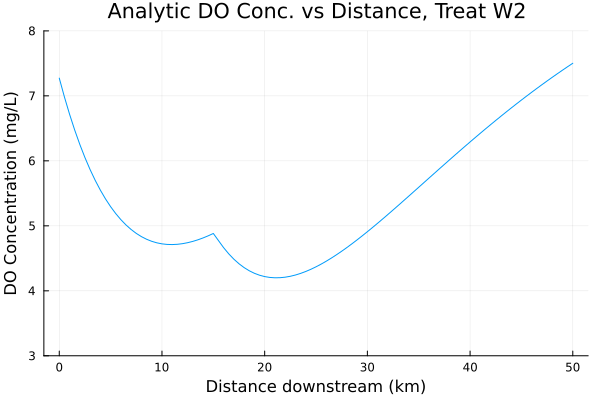

In [89]:
# Constants
U = 6.0            # km/day
k_a = 0.55         # /day
k_c = 0.35         # /day
k_n = 0.25         # /day
C_s = 10.0         # mg/L

# Flows (m³/day)
Q_r = 100000.0
Q1  = 10000.0
Q2  = 15000.0

Q_m1 = Q_r + Q1 
Q_total = Q_m1 + Q2

# Inflow concentrations
C_r = 7.5
B_r = 5.0
N_r = 5.0

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0
N1_ws = 35.0

# Add variable R representing reduction of CBOD + NBOD
R = 0.7825

# Waste stream 2
C2_ws = 5.0
B2_ws = 45.0*R
N2_ws = 35.0*R

# Mixing after first waste stream
C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

# Recalibrate values at 15 km before mixing
t = 15 / U
a1_15 = exp(-k_a * t)
a2_15 = (k_c / (k_a - k_c)) * (exp(-k_c * t) - exp(-k_a * t))
a3_15 = (k_n / (k_a - k_n)) * (exp(-k_n * t) - exp(-k_a * t))
C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
B_15 = B0_1 * exp(-k_c * t)
N_15 = N0_1 * exp(-k_n * t)

# Mixing with second waste stream at 15 km
C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

# Define analytic functions
function do_analytic_1(C0, B0, N0, k_a, k_n, k_c, C_s, U)
    x1 = 0:0.5:15
    C1 = Float64[]

    for x in x1
        a1 = exp(-k_a * x / U)
        a2 = (k_c / (k_a - k_c)) * (exp(-k_c * x / U) - exp(-k_a * x / U))
        a3 = (k_n / (k_a - k_n)) * (exp(-k_n * x / U) - exp(-k_a * x / U))
        C = C_s * (1 - a1) + C0 * a1 - B0 * a2 - N0 * a3
        push!(C1, C)
    end

    return x1, C1
end

function do_analytic_2(C0, B0, N0, k_a, k_n, k_c, C_s, U)
    x2 = 15:0.5:50
    C2 = Float64[]

    for x in x2
        dx = x - 15
        a1 = exp(-k_a * dx / U)
        a2 = (k_c / (k_a - k_c)) * (exp(-k_c * dx / U) - exp(-k_a * dx / U))
        a3 = (k_n / (k_a - k_n)) * (exp(-k_n * dx / U) - exp(-k_a * dx / U))
        C = C_s * (1 - a1) + C0 * a1 - B0 * a2 - N0 * a3
        push!(C2, C)
    end

    return x2, C2
end

x1, C1 = do_analytic_1(C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
x2, C2 = do_analytic_2(C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)

DO_distance_analytic = vcat(x1, x2[2:end])      
DO_concentration_analytic = vcat(C1, C2[2:end])

min_DO = minimum(DO_concentration_analytic)
min_index = argmin(DO_concentration_analytic)
min_distance = DO_distance_analytic[min_index]

println("Minimum DO Concentration: $(min_DO) mg/L")
println("Occurs at: $(min_distance) km downstream")

min_treatment = (1-R)*100
println("Minimum Level of Treatment: $(round(min_treatment, digits=2)) %")

plot(DO_distance_analytic, DO_concentration_analytic, xlabel = "Distance downstream (km)", ylabel = "DO Concentration (mg/L)", title = "Analytic DO Conc. vs Distance, Treat W2", legend = false, ylim = (3, 8))

#### When only waste stream 1 is treated, a minimum treatment level of 27.58% must be applied. When only waste stream 2 is treated, a minimum level of 21.75% must be applied.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

#### From the initial graph from 1.1, we saw that the DO level did not dip below 4 mg/L (or, with the safety factor, 4.2 mg/L) until after the input from waste stream 2. Following the analysis above, waste stream 1 requires a treatment level of at least 27.58%, while waste stream 2 requires a slightly lower treatment level of 21.75%. Since the DO level does not dip below the standard with safety factor before the input from stream 2 and a lower treatment level would be expected to require fewer resources and monetary expenses in a real-world context, I would only treat waste stream 2. 
#### That said, the two sources are 15 km apart, and the nature of the sources are not specified. Depending on the infrastructure/terrain at each location, it could end up being logistically easier to only treat waste stream 1. In the same vein, it may be more expensive to treat stream 2 compared to stream 1, which presents another consideration from an economic standpoint. Additionally, this hypothetical river could very well be located across US state boundaries, in which case minimum DO concentrations for both states should be considered as states are permitted to have stricter standards for water quality parameters than the federal level; this would directly affect the level of treatment needed. Lastly, any projected changes in waste stream inputs in the near future would also be relevant - if either stream experiences a notable increase/decrease in CBOD and NBOD in the near future due to human activity or environmental changes, this would affect the previous calculations and the resulting minimum treatment levels required to meet the DO standard.

### Problem 1.5

* Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
* Conduct a Monte Carlo simulation of the DO concentration in the river.
* If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? 
* How did you decide that your Monte Carlo sample size was sufficiently large?

In [102]:
Random.seed!(1)

TaskLocalRNG()

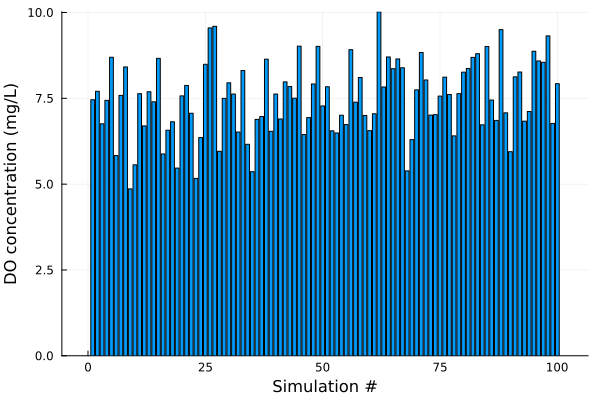

In [103]:
# Apply LogNormal probability distribution for DO concentration of river inflow
C_river = 7.5 #mg/L

ln_distribution = LogNormal(2.0, 0.15)
ln_DO_river = rand(ln_distribution,100)

bar(ln_DO_river, legend=:false, bins=100)
ylabel!("DO concentration (mg/L)")
xlabel!("Simulation #")

In [107]:
# Output Monte Carlo estimates
mean_distribution = mean(ln_DO_river)
println("  Mean Monte Carlo estimate of DO concentration at river inflow: $(mean_distribution)")

  Mean Monte Carlo estimate of DO concentration at river inflow: 7.499975701248864


#### Monte Carlo Simulation of DO Concentration in River, Both Waste Streams Untreated

Average Minimum DO Concentration: 3.754203056938112 mg/L
Average Location of Minimum DO: 22.325 km downstream


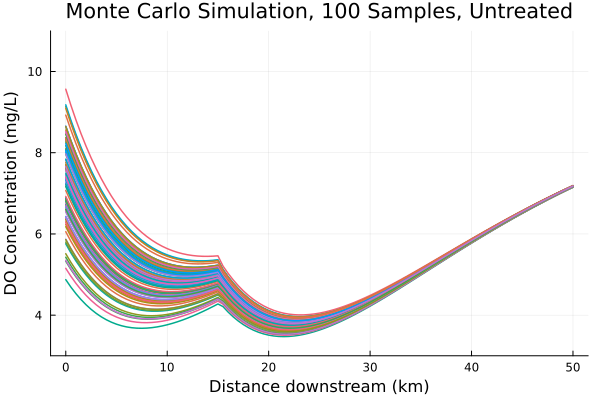

In [108]:
# Constants
U = 6.0            # km/day
k_a = 0.55         # /day
k_c = 0.35         # /day
k_n = 0.25         # /day
C_s = 10.0         # mg/L

# Flows (m³/day)
Q_r = 100000.0
Q1  = 10000.0
Q2  = 15000.0

Q_m1 = Q_r + Q1 
Q_total = Q_m1 + Q2

# Inflow concentrations
C_r = 7.5
B_r = 5.0
N_r = 5.0

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0
N1_ws = 35.0

# Waste stream 2
C2_ws = 5.0
B2_ws = 45.0
N2_ws = 35.0

# Account for all projections with all samples
all_profiles = Vector{Tuple{Vector{Float64}, Vector{Float64}}}()
min_DO_vals = Float64[]
min_dist_vals = Float64[]

# Take values from the LogNormal distribution above as the river input and use same equations as earlier
for C_r in ln_DO_river

    C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
    B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
    N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

    # Recalibrate at 15 km before mixing
    t = 15 / U
    a1_15 = exp(-k_a * t)
    a2_15 = (k_c / (k_a - k_c)) * (exp(-k_c * t) - exp(-k_a * t))
    a3_15 = (k_n / (k_a - k_n)) * (exp(-k_n * t) - exp(-k_a * t))
    C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
    B_15 = B0_1 * exp(-k_c * t)
    N_15 = N0_1 * exp(-k_n * t)

    # Mixing with second waste stream at 15 km
    C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
    B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
    N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

    # Calculate DO along river
    x1, C1 = do_analytic_1(C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
    x2, C2 = do_analytic_2(C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)

    DO_distance = vcat(x1, x2[2:end])
    DO_concentration = vcat(C1, C2[2:end])

    # Store each profile
    push!(all_profiles, (DO_distance, DO_concentration))

    # Store minimum DO
    min_DO = minimum(DO_concentration)
    min_index = argmin(DO_concentration)
    min_distance = DO_distance[min_index]
    push!(min_DO_vals, min_DO)
    push!(min_dist_vals, min_distance)
end

println("Average Minimum DO Concentration: $(mean(min_DO_vals)) mg/L")
println("Average Location of Minimum DO: $(mean(min_dist_vals)) km downstream")

plt = plot(title="Monte Carlo Simulation, 100 Samples, Untreated", xlabel="Distance downstream (km)", ylabel="DO Concentration (mg/L)", ylim=(3, 11), legend=false)

for (dist, conc) in all_profiles
    plot!(plt, dist, conc, lw=1.5)
end

display(plt)

#### Monte Carlo Simulation of DO Concentration in River, Waste Stream 1 Treated

Average Minimum DO Concentration: 4.198125957450939 mg/L
Average Location of Minimum DO: 22.73 km downstream


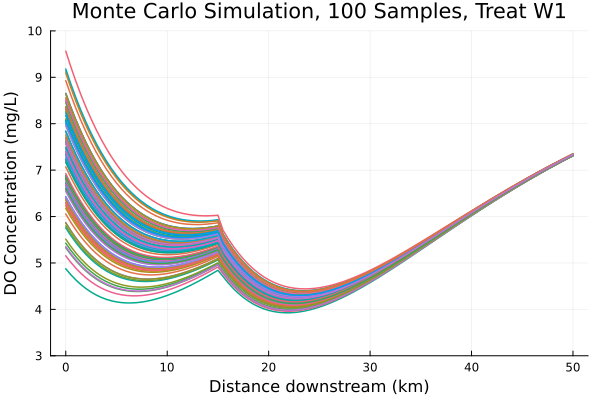

In [116]:
# Add variable R representing reduction of CBOD + NBOD
R = 0.7242

# Waste stream 1
C1_ws = 5.0
B1_ws = 50.0*R
N1_ws = 35.0*R

all_profiles = Vector{Tuple{Vector{Float64}, Vector{Float64}}}()
min_DO_vals = Float64[]
min_dist_vals = Float64[]

# Take values from the LogNormal distribution above as the river input and use same equations as earlier
for C_r in ln_DO_river

    C0_1 = (Q_r*C_r + Q1*C1_ws) / Q_m1
    B0_1 = (Q_r*B_r + Q1*B1_ws) / Q_m1
    N0_1 = (Q_r*N_r + Q1*N1_ws) / Q_m1

    # Recalibrate at 15 km before mixing
    t = 15 / U
    a1_15 = exp(-k_a * t)
    a2_15 = (k_c / (k_a - k_c)) * (exp(-k_c * t) - exp(-k_a * t))
    a3_15 = (k_n / (k_a - k_n)) * (exp(-k_n * t) - exp(-k_a * t))
    C_15 = C_s * (1 - a1_15) + C0_1 * a1_15 - B0_1 * a2_15 - N0_1 * a3_15
    B_15 = B0_1 * exp(-k_c * t)
    N_15 = N0_1 * exp(-k_n * t)

    # Mixing with second waste stream at 15 km
    C0_2 = (Q_m1*C_15 + Q2*C2_ws) / Q_total
    B0_2 = (Q_m1*B_15 + Q2*B2_ws) / Q_total
    N0_2 = (Q_m1*N_15 + Q2*N2_ws) / Q_total

    # Calculate DO along river
    x1, C1 = do_analytic_1(C0_1, B0_1, N0_1, k_a, k_n, k_c, C_s, U)
    x2, C2 = do_analytic_2(C0_2, B0_2, N0_2, k_a, k_n, k_c, C_s, U)

    DO_distance = vcat(x1, x2[2:end])
    DO_concentration = vcat(C1, C2[2:end])

    # Store each profile
    push!(all_profiles, (DO_distance, DO_concentration))

    # Store minimum DO
    min_DO = minimum(DO_concentration)
    min_index = argmin(DO_concentration)
    min_distance = DO_distance[min_index]
    push!(min_DO_vals, min_DO)
    push!(min_dist_vals, min_distance)
end

println("Average Minimum DO Concentration: $(mean(min_DO_vals)) mg/L")
println("Average Location of Minimum DO: $(mean(min_dist_vals)) km downstream")

plt = plot(title="Monte Carlo Simulation, 100 Samples, Treat W1", xlabel="Distance downstream (km)", ylabel="DO Concentration (mg/L)", ylim=(3, 10), legend=false)

for (dist, conc) in all_profiles
    plot!(plt, dist, conc, lw=1.5)
end

display(plt)

#### Expected probability and 95% Confidence Interval

In [117]:
fails = min_DO_vals .< 4.0
p_fail = mean(fails)
n = length(fails)

z = 1.96 
se = sqrt(p_fail * (1 - p_fail) / n)
lower_CI = max(0, p_fail - z * se)
upper_CI = min(1, p_fail + z * se)

println("Expected probability (DO < 4 mg/L): $(round(p_fail*100, digits=4)) %")
println("95% Confidence Interval: [$(round(lower_CI*100, digits=4)) %, $(round(upper_CI*100, digits=4)) %]")

Expected probability (DO < 4 mg/L): 5.0 %
95% Confidence Interval: [0.7283 %, 9.2717 %]


#### Applying safety factor of 5%

In [118]:
fails = min_DO_vals .< 4.2
p_fail = mean(fails)
n = length(fails)

z = 1.96 
se = sqrt(p_fail * (1 - p_fail) / n)
lower_CI = max(0, p_fail - z * se)
upper_CI = min(1, p_fail + z * se)

println("Expected probability (DO < 4.2 mg/L): $(round(p_fail*100, digits=4)) %")
println("95% Confidence Interval: [$(round(lower_CI*100, digits=4)) %, $(round(upper_CI*100, digits=4)) %]")

Expected probability (DO < 4.2 mg/L): 47.0 %
95% Confidence Interval: [37.2177 %, 56.7823 %]


The 95% confidence interval is 0.7283 - 9.217%; when the 5% safety factor is applied this interval becomes 37.2177 - 56.7823%. There is only a 5% probability that the river fails to comply with the standard of 4 mg/L, however when the safety factor of 5% is applied, this probability jumps to 47%. This dramatic increase suggests that when only waste stream 1 is treated at the 27.58% treatment level determined in 1.4, the minimum DO is generally between 4 - 4.2 mg/L. Although this simulation does suggest that treating only waste stream 1 is effective at meeting the compliance limit, to be on the safe side and account for a 5% safety factor, it would be a better decision to either increase the treatment level applied to waste stream 1 or switch to treating waste stream 2, which requires a lower level of treatment to achieve the same standards.

## References

List any external references consulted, including classmates.

* TA office hours
* Professor office hours
* https://dataframes.juliadata.org/stable/lib/functions/ 